In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import json
from scipy.interpolate import make_interp_spline
from helper import compute_poi_ul

# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [2]:
# Load combined json file (created with collectData.py)
jsonFile = 'atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']

## Plot Efficiency Uncertainties

20


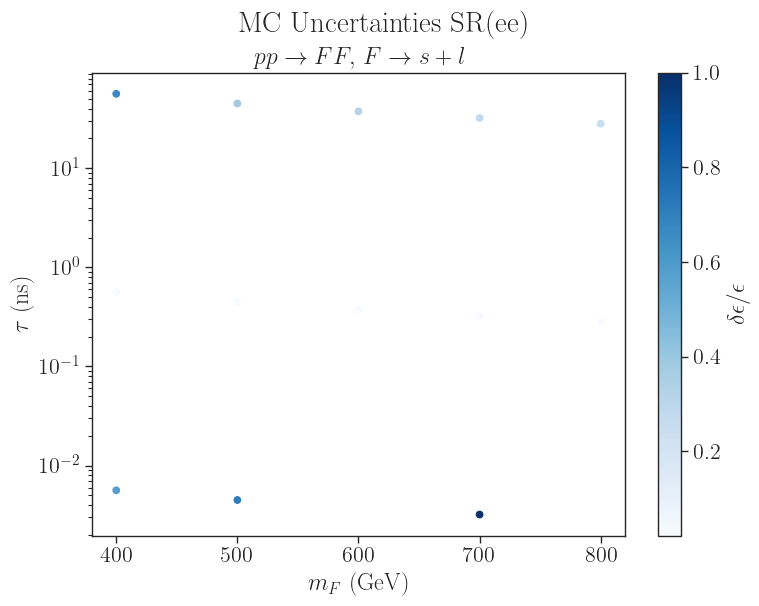

In [4]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

title = r'$p p \to F F,\, F \to s + l$'
# Select only points with very light DM
df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == 0.1]
print(len(df))
x = df['mLLP']
y = df['tau0_ns']
tit_append = ''
z = df['AccEffCuts_ee_err']/df['AccEffCuts_ee']

im = ax.scatter(x,y,c=z,cmap='Blues')
ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{F}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$\delta \epsilon / \epsilon$')

ax.set_title(title)

plt.tight_layout()
plt.suptitle('MC Uncertainties SR(ee)', y=1.02)
plt.show()

## Plot Exclusion Curve

### Get ATLAS official exclusion curve for selectron pair production

In [8]:
atlas_curve = np.genfromtxt('./ATLAS_data/HEPData-ins1831504-v2-csv/Observedselectronlimits.csv',
                            delimiter=',',comments='#')
atlas_curve = atlas_curve[~np.isnan(atlas_curve[:,0])]

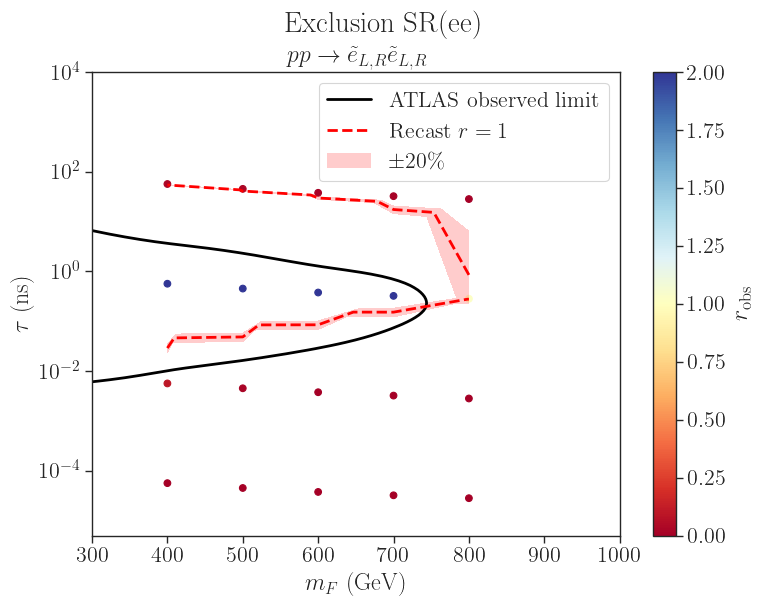

In [14]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

df = dfRecast[dfRecast['m5000022']/dfRecast['mLLP'] == 0.1]

x = df['mLLP']
y = df['tau0_ns']
r = 1.0/df['muUL_observed']

# im = ax.scatter(x,y,c=z,cmap=cm,norm=LogNorm(vmin=max(1e-8,min(z)),vmax=max(z)))
im = ax.scatter(x,y,c=r,cmap=cm,vmin=0,vmax=2)

# for xi, yi, zi in zip(x, y, r):
    # if zi > 2.0 or zi < 0.5:
        # continue
    # ax.annotate(f'{zi:.1f}', (xi, yi), textcoords='offset points', xytext=(2, 4), fontsize=8, rotation=0)

# Filled 20% band around exclusion threshold: 0.8 <= r <= 1.2
band_r = ax.tricontourf(
    x.to_numpy(),
    y.to_numpy(),
    r.to_numpy(),
    levels=[0.8, 1.2],
    colors=['red'],
    alpha=0.2,
    zorder=2
)

# Recast observed-like contour from r = 1
cont_r1 = ax.tricontour(
    x.to_numpy(),
    y.to_numpy(),
    r.to_numpy(),
    levels=[1.0],
    colors='red',
    linewidths=2.0,
    linestyles='--',
    zorder=3
    )

atlas_line, = ax.plot(atlas_curve[:,0], atlas_curve[:,1], label='ATLAS observed limit',linewidth=2,c='black')

ax.set_yscale('log')
ax.set_ylabel(r'$\tau$ (ns)')
ax.set_xlabel(r'$m_{F}$ (GeV)')
fig.colorbar(im, ax=ax, label=r'$r_{\rm obs}$')

ax.set_title(title)
ax.set_xlim(300.,1000.)
ax.set_ylim(5e-6,1e4)

# Use a proxy artist so the r=1 contour appears with a dashed line in the legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
recast_proxy = Line2D([0], [0], color='red', linestyle='--', linewidth=2.0, label=r'Recast $r=1$')
band_proxy = Patch(facecolor='red', alpha=0.2, edgecolor='none', label=r'$\pm 20$\%')
ax.legend(handles=[atlas_line, recast_proxy, band_proxy])

plt.tight_layout()
plt.suptitle('Exclusion SR(ee)', y=1.02)
plt.show()